<a href="https://colab.research.google.com/github/Ilanahai/AWS---Data-analytics-project/blob/main/Tracking_User_Engagement_with_SQL%2C_Excel%2C_and_Python_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# Step 1 & 2: Import Libraries**

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

**# Step 3: Load the Data**

In [ ]:
data_free_2021 = pd.read_csv('minutes_watched_2021_paid_0.csv')
data_free_2022 = pd.read_csv('minutes_watched_2022_paid_0.csv')
data_paid_2021 = pd.read_csv('minutes_watched_2021_paid_1.csv')
data_paid_2022 = pd.read_csv('minutes_watched_2022_paid_1.csv')

**# Step 4: Explore Data**

In [ ]:
print(data_free_2021.head())
print(data_paid_2022.head())

   student_id  minutes_watched  paid_in_q2
0           6            81.03           1
1         516            46.27           1
2         520            91.18           1
3         523          1322.25           1
4         594             3.73           1
   student_id  minutes_watched
0         618           952.60
1        2731           468.67
2        2811           575.72
3        2954           163.12
4        5704             0.10


**# Step 5: Plot Distributions (Before Outlier Removal)**

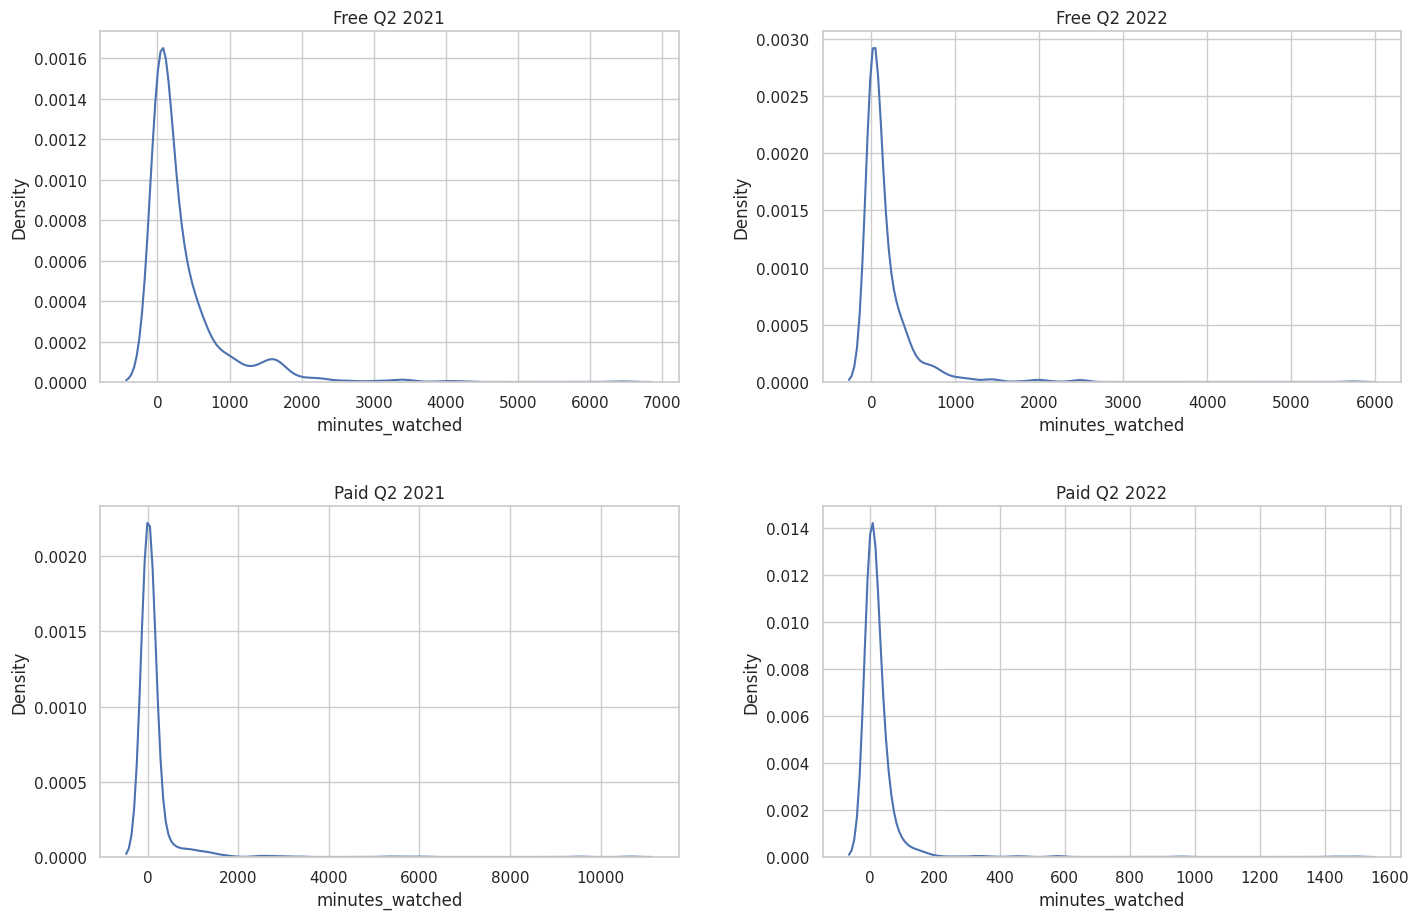

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))
sns.kdeplot(data_free_2021['minutes_watched'], ax=axes[0,0]).set(title='Free Q2 2021')
sns.kdeplot(data_free_2022['minutes_watched'], ax=axes[0,1]).set(title='Free Q2 2022')
sns.kdeplot(data_paid_2021['minutes_watched'], ax=axes[1,0]).set(title='Paid Q2 2021')
sns.kdeplot(data_paid_2022['minutes_watched'], ax=axes[1,1]).set(title='Paid Q2 2022')
fig.tight_layout(pad=3.0)
plt.show()

**# Step 6: Find 99th Percentiles**

In [ ]:
def remove_outliers(df):
    q99 = df['minutes_watched'].quantile(0.99)
    return df[df['minutes_watched'] < q99]

data_free_2021_clean = remove_outliers(data_free_2021)
data_free_2022_clean = remove_outliers(data_free_2022)
data_paid_2021_clean = remove_outliers(data_paid_2021)
data_paid_2022_clean = remove_outliers(data_paid_2022)

**# Step 7: Remove Outliers**

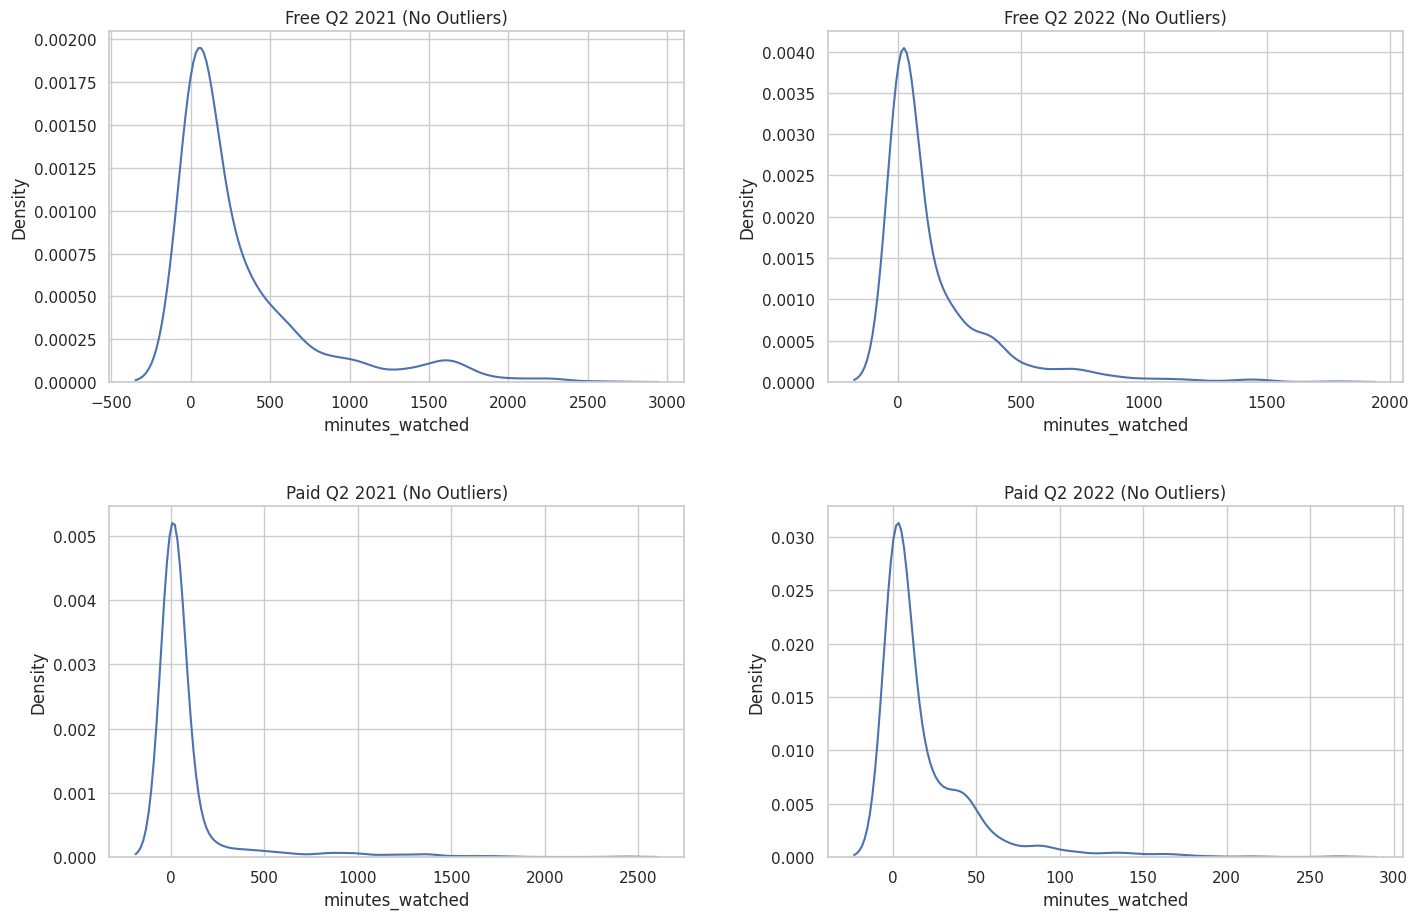

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))
sns.kdeplot(data_free_2021_clean['minutes_watched'], ax=axes[0,0]).set(title='Free Q2 2021 (No Outliers)')
sns.kdeplot(data_free_2022_clean['minutes_watched'], ax=axes[0,1]).set(title='Free Q2 2022 (No Outliers)')
sns.kdeplot(data_paid_2021_clean['minutes_watched'], ax=axes[1,0]).set(title='Paid Q2 2021 (No Outliers)')
sns.kdeplot(data_paid_2022_clean['minutes_watched'], ax=axes[1,1]).set(title='Paid Q2 2022 (No Outliers)')
fig.tight_layout(pad=3.0)
plt.show()

**# Step 8: Save Cleaned Data**

In [ ]:
data_free_2021_clean.to_csv('minutes_watched_2021_paid_0_no_outliers.csv', index=False)
data_free_2022_clean.to_csv('minutes_watched_2022_paid_0_no_outliers.csv', index=False)
data_paid_2021_clean.to_csv('minutes_watched_2021_paid_1_no_outliers.csv', index=False)
data_paid_2022_clean.to_csv('minutes_watched_2022_paid_1_no_outliers.csv', index=False)

print("Task 4 completed: Outliers removed and cleaned CSV files saved.")

Task 4 completed: Outliers removed and cleaned CSV files saved.
